<a href="https://colab.research.google.com/github/manthakiran/Deep-Learning/blob/main/Nike_vs_Adidas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
from tqdm import tqdm
from random import shuffle

In [2]:
Test_dir = '/content/Test_data'
Train_dir = '/content/Train_data'

In [3]:
Img_size = 120
model_name = 'NIKEvsADIDAS'

In [4]:
def label_img(img):
  word_label = img.split('_')[0]
  if word_label == 'NIKE': return [1,0]
  elif word_label == 'ADIDAS': return [0,1]


In [5]:
def create_train_data():
  train_data = []
  for img in tqdm(os.listdir(Train_dir)):
    label = label_img(img)
    path = os.path.join(Train_dir,img)
    img = Image.open(path)
    img = img.convert('L')
    img = img.resize((Img_size,Img_size),Image.Resampling.LANCZOS)
    train_data.append([np.array(img),np.array(label)])
  shuffle(train_data)
  # np.save('train_data.npy',train_data)
  return train_data

In [6]:
train_data = create_train_data()

100%|██████████| 87/87 [00:00<00:00, 194.61it/s]


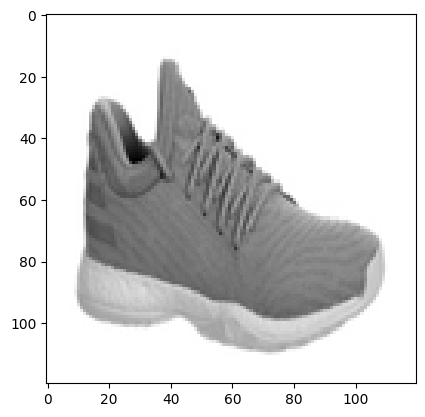

In [7]:
plt.imshow(train_data[1][0],cmap='gist_gray')
plt.show()

In [8]:
# Buliding the N/W

In [9]:
import keras
from keras.layers import Conv2D,MaxPooling2D
from keras.models import Sequential
from keras.layers import Dense,Dropout,Activation,Flatten

In [10]:
model = Sequential()
model.add(Conv2D(16,3,activation='relu',input_shape = (120,120,1)))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(32,3,activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(64,3,activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())

model.add(Dense(64,activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(2,activation='softmax'))

model.compile(loss='categorical_crossentropy',optimizer='adam',metrics=['accuracy'])



/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
x = np.array([i[0] for i in train_data]).reshape(-1,Img_size,Img_size,1)
y = np.array([i[1] for i in train_data])

model.fit(x,y,epochs=10)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 332ms/step - accuracy: 0.5287 - loss: 52.4446
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 312ms/step - accuracy: 0.4483 - loss: 19.4367
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 297ms/step - accuracy: 0.5632 - loss: 4.3973
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 312ms/step - accuracy: 0.6322 - loss: 0.7367
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 321ms/step - accuracy: 0.7126 - loss: 0.4978
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 308ms/step - accuracy: 0.8851 - loss: 0.3658
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 321ms/step - accuracy: 0.7931 - loss: 0.3532
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 674ms/step - accuracy: 0.9770 - loss: 0.1943
Epoch 9/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 527ms/step - accuracy: 0.9540 - loss: 0.1428
Epoch 10/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 495ms/step - accuracy: 0.9770 - loss: 0.0955


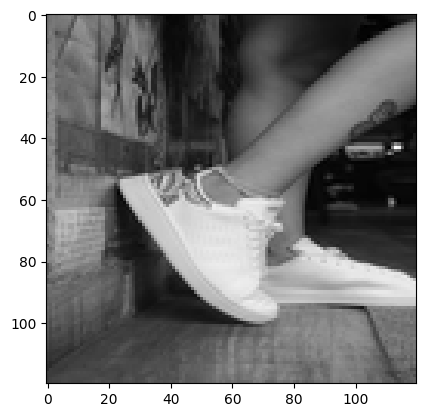

In [12]:
# PIL
img = Image.open('/content/shoe.jpg')
img = img.convert('L')
img = img.resize((Img_size, Img_size), Image.Resampling.LANCZOS)

plt.imshow(np.array(img), cmap='gist_gray')
plt.show()

In [13]:
model.predict(np.array(img).reshape(-1,Img_size,Img_size,1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step


array([[0.00550937, 0.9944906 ]], dtype=float32)

In [15]:
test_loss, test_acc = model.evaluate(x, y)
print("Test accuracy:", test_acc)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - accuracy: 0.9885 - loss: 0.0505
Test accuracy: 0.9885057210922241
